In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from scipy import stats

plt.rcParams['figure.figsize'] = 21, 15
plt.rcParams['xtick.labelsize']=65
plt.rcParams['ytick.labelsize']=65
plt.rcParams['ytick.right'] = plt.rcParams['ytick.labelright'] = False
plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = True
plt.rcParams.update({'figure.autolayout': False})
plt.rcParams['axes.linewidth'] = 5
plt.rcParams['font.family'] = 'Arial'

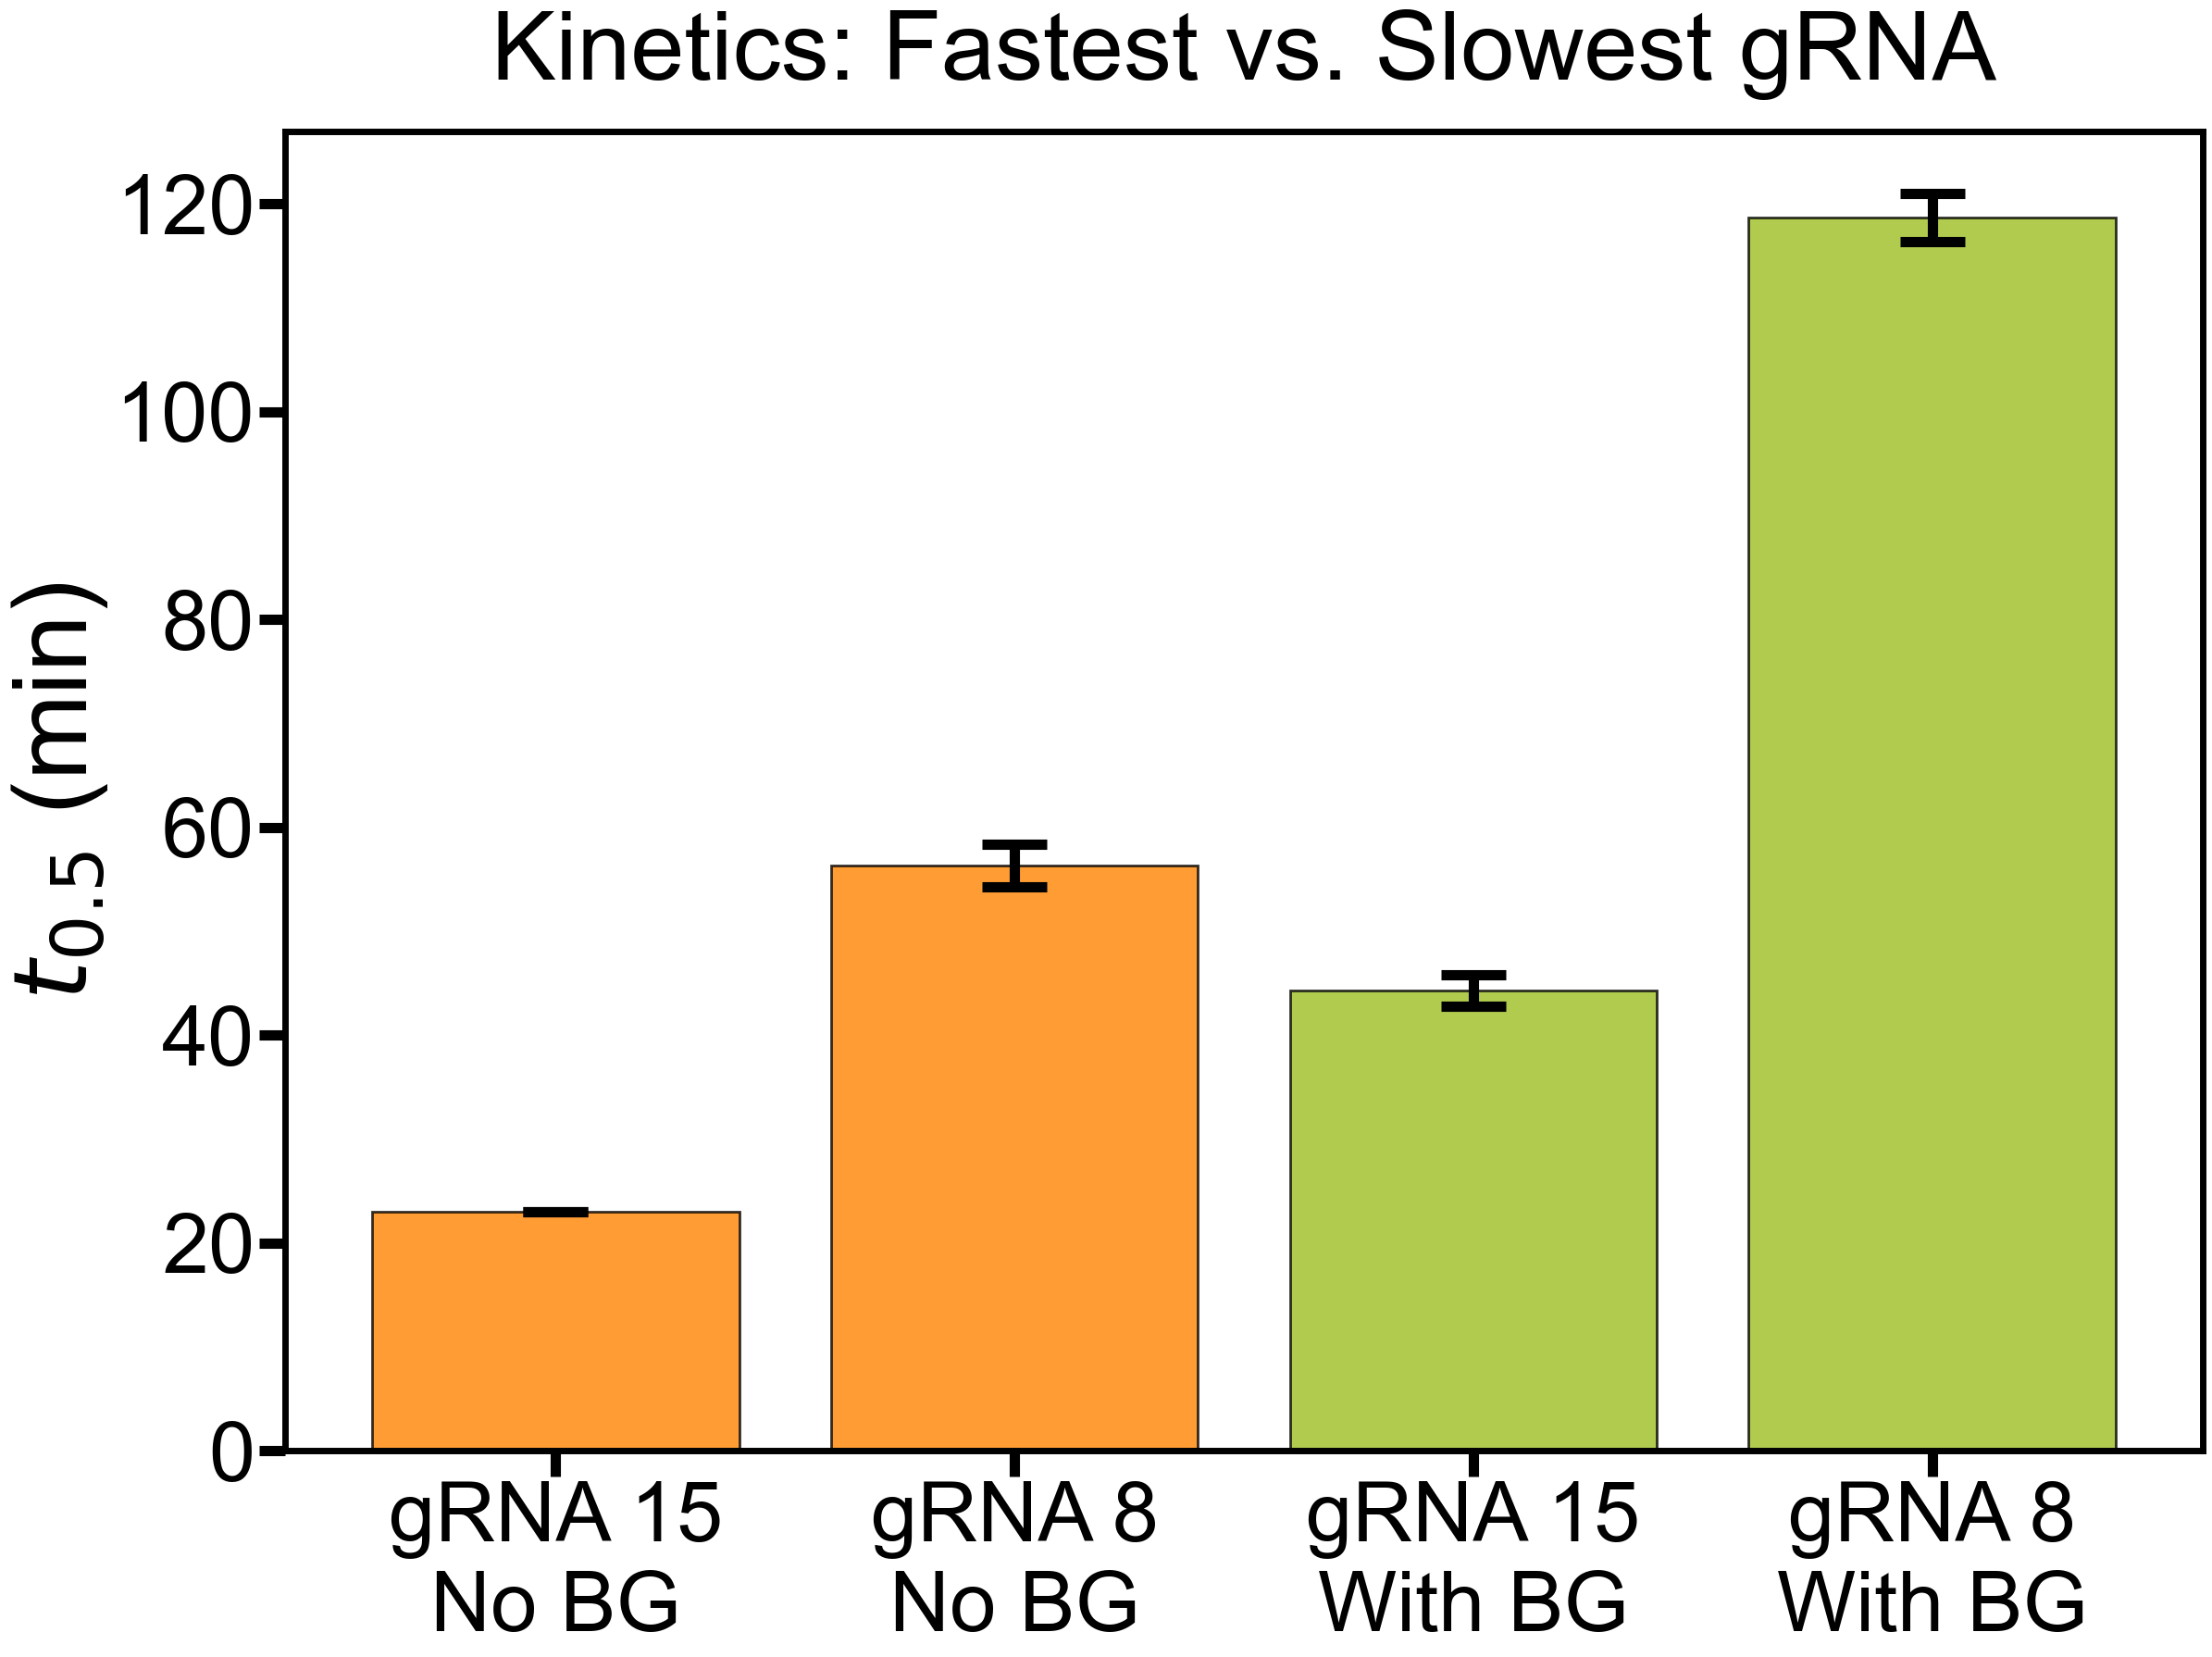


--- NUMERICALLY SORTED MATRIX (Minutes) ---
gRNA Name  t0.5 No BG  t0.5 With BG  Ratio
   gRNA 1       30.33         67.00   2.21
   gRNA 2       25.33         58.00   2.29
   gRNA 3       52.67        160.67   3.05
   gRNA 4       38.00         57.00   1.50
   gRNA 5       34.00         90.67   2.67
   gRNA 6       27.33         81.00   2.96
   gRNA 7       36.33        151.33   4.17
   gRNA 8       56.33        118.67   2.11
   gRNA 9       30.00         45.00   1.50
  gRNA 10       54.00        139.67   2.59
  gRNA 11       47.00        109.67   2.33
  gRNA 12       51.33        104.67   2.04
  gRNA 13       46.33        117.67   2.54
  gRNA 14       36.00         49.00   1.36
  gRNA 15       23.00         44.33   1.93
  gRNA 16       36.00         85.33   2.37
  gRNA 17       47.33         98.67   2.08


In [18]:
files = ["Figure3-DNA-Background.xlsx", "Figure4.xlsx"]
all_dfs = [pd.read_excel(f) for f in files]

def get_t100_stats(df, cols):
    times = []
    for c in cols:
        above = df[df[c] > 100]
        if not above.empty:
            # CONVERSION: seconds to minutes
            times.append(above.iloc[0]["time"] / 60) 
    return times if times else [np.nan]

rows = []
for df in all_dfs:
    dna_cols = [c for c in df.columns if "DNA" in str(c) and c != "time"]
    non_dna_cols = [c for c in df.columns if "DNA" not in str(c) and c != "time"]
    
    def group_cols(cols):
        g = defaultdict(list)
        for c in cols:
            base = re.sub(r"\.\d+$", "", str(c)).strip()
            g[base].append(c)
        return g

    dna_groups = group_cols(dna_cols)
    no_bg_groups = group_cols(non_dna_cols)

    for dna_key, dna_col_list in dna_groups.items():
        clean_label = dna_key.replace(" DNA", "").strip()
        match_key = next((k for k in no_bg_groups if k.strip() == clean_label), None)
        
        if match_key:
            dna_vals = get_t100_stats(df, dna_col_list)
            ref_vals = get_t100_stats(df, no_bg_groups[match_key])
            
            # Rounding to 2 decimal places during calculation
            rows.append({
                "gRNA": clean_label,
                "no_bg_mean": round(np.mean(ref_vals), 2),
                "no_bg_std": round(np.std(ref_vals, ddof=1), 2) if len(ref_vals) > 1 else 0,
                "with_bg_mean": round(np.mean(dna_vals), 2),
                "with_bg_std": round(np.std(dna_vals, ddof=1), 2) if len(dna_vals) > 1 else 0,
                "ratio": round(np.mean(dna_vals) / np.mean(ref_vals), 2)
            })

matrix_df = pd.DataFrame(rows).drop_duplicates(subset=['gRNA'])

fastest = matrix_df.loc[matrix_df['no_bg_mean'].idxmin()]
slowest = matrix_df.loc[matrix_df['no_bg_mean'].idxmax()]

labels = [
    f"{fastest['gRNA']}\nNo BG", f"{slowest['gRNA']}\nNo BG",
    f"{fastest['gRNA']}\nWith BG", f"{slowest['gRNA']}\nWith BG"
]
means = [fastest['no_bg_mean'], slowest['no_bg_mean'], fastest['with_bg_mean'], slowest['with_bg_mean']]
stds = [fastest['no_bg_std'], slowest['no_bg_std'], fastest['with_bg_std'], slowest['with_bg_std']]

color_no_bg = '#ff8300'
color_with_bg = '#9cbf22'
bar_colors = [color_no_bg, color_no_bg, color_with_bg, color_with_bg]

fig, ax = plt.subplots(figsize=(24, 18))

bars = ax.bar(
    labels, means, yerr=stds, capsize=25, color=bar_colors,
    edgecolor='black', linewidth=2, alpha=0.8,
    error_kw={"elinewidth": 8, "capthick": 8}
)

ax.set_ylabel("$t_{0.5}$ (min)", fontsize=80)
ax.tick_params(axis='both', which='major', length=20, width=8, labelsize=65)
ax.set_title("Kinetics: Fastest vs. Slowest gRNA", fontsize=75, pad=40)

plt.tight_layout()
plt.savefig("Kinetic_Variation_Minutes.svg", format="svg")
plt.show()

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

matrix_df = matrix_df.sort_values(by="gRNA", key=lambda x: x.map(natural_sort_key))

final_matrix = matrix_df[["gRNA", "no_bg_mean", "with_bg_mean", "ratio"]].copy()
final_matrix.columns = ["gRNA Name", "t0.5 No BG", "t0.5 With BG", "Ratio"]
final_matrix.to_excel("gRNA_Kinetic_Matrix.xlsx", index=False)

print("\n--- NUMERICALLY SORTED MATRIX (Minutes) ---")
print(final_matrix.to_string(index=False))